In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import os

from torch.utils.benchmark.examples.spectral_ops_fuzz_test import BENCHMARK_MAP

In [10]:
BENCHMARK_RESULTS_DIR = "."
Q_FLAIR_RESULTS_DIR = "../Results/Data_QNN"

# Load accuracy results

In [11]:
def line_to_dict(line: str):
    line = line.strip().split()
    return dict(zip(line[::2], line[1::2]))

def load(bench_folder, max_n_gate, acc_format_filename="ACC_classical_surrogate_{}.txt"):
    model_infos = []
    accuracy_dfs = []
    for n_gate in range(1, max_n_gate + 1):
        acc_filename = os.path.join(BENCHMARK_RESULTS_DIR, bench_folder, acc_format_filename.format(n_gate))
        # print first line:
        with open(acc_filename, 'r') as f:
            first_line = f.readline()
            model_infos.append(line_to_dict(first_line))
            accuracy_dicts = []
            for line in f:
                if line.strip() == "":
                    continue
                accuracy_dicts.append(line_to_dict(line))
            if len(accuracy_dicts) > 0:
                acc_df = pd.DataFrame(accuracy_dicts).apply(pd.to_numeric, errors='ignore')
                accuracy_dfs.append(acc_df)
    return model_infos, accuracy_dfs

def combine_accuracies(accuracy_dfs, max_col_name):
    results = []
    for n_gate, df in enumerate(accuracy_dfs):
        if df is None:
            continue
        max_row = df.loc[df[max_col_name].idxmax()]
        results.append({'n_gate': n_gate + 1, **max_row.to_dict()})
    aggregated_results = pd.DataFrame(results)
    return aggregated_results

# Visualize

In [103]:
def plot_classical_surrogate_acc(bench_folder, max_n_gate, max_col_name, ax=None, add_best_line=False, include_train_acc=False, data_set_color='blue'):
    model_infos, acc_dfs = load(bench_folder, max_n_gate=max_n_gate)
    comb_df = combine_accuracies(acc_dfs, max_col_name=max_col_name)
    if ax is None:
        ax = plt.gca()
    if include_train_acc:
        ax.plot(comb_df['n_gate'], 100 * comb_df['train_acc'], label='Classical\nSurrogate (Train)', color='grey', linestyle='--')
    ax.plot(comb_df['n_gate'], 100 * comb_df['val_acc'], label='Classical\nSurrogate', linestyle='--', color=data_set_color)
    if add_best_line:
        best_acc = comb_df['val_acc'].max()
        ax.axhline(100 * best_acc, linestyle=':', label='Best Accuracy', color='black')
    return model_infos, comb_df

([{'num_unique_feats': '1',
   'num_freqs': '1',
   'all_freqs': '{"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '2',
   'num_freqs': '4',
   'all_freqs': '{"4":[-0.166,0.0,0.166],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '13',
   'all_freqs': '{"4":[-0.166,0.0,0.166],"8":[-0.36,0.0,0.36],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '40',
   'all_freqs': '{"4":[-0.542,-0.376,-0.21,-0.166,0.0,0.166,0.21,0.376,0.542],"8":[-0.36,0.0,0.36],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '121',
   'all_freqs': '{"4":[-0.542,-0.376,-0.21,-0.166,0.0,0.166,0.21,0.376,0.542],"8":[-0.7,-0.36,-0.34,-0.02,0.0,0.02,0.34,0.36,0.7],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '364',
   'all_freqs': '{"4":[-0.82,-0.654,-0.542,-0.488,-0.444,-0.376,-0.278,-0.264,-0.21,-0.166,-0.112,-0.098,-0.068,0.0,0.068,0.098,0.112,0.166,0.21,0.264,0.278,0.376,0.444,0.488,0.542,0.654,0.82],"8":[-0.7,-0.36,-

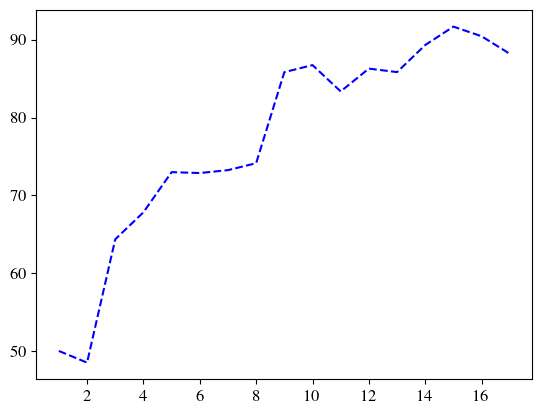

In [104]:
plot_classical_surrogate_acc("logLossBS", max_n_gate=125, max_col_name="train_acc")

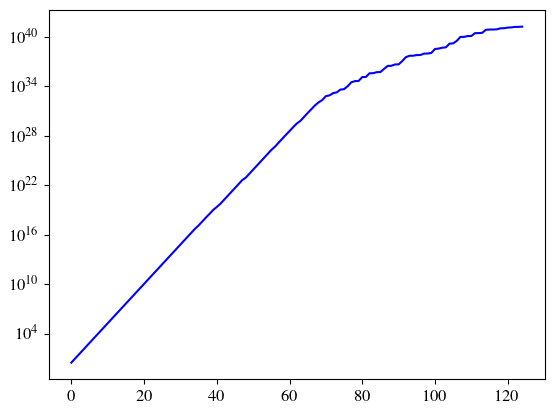

In [105]:
def plot_classical_surrogate_param_counts(bench_folder, max_n_gate, data_set_color='blue', ax=None):
    if ax is None:
        ax = plt.gca()
    model_infos, _ = load(bench_folder, max_n_gate=max_n_gate)
    model_param_counts = [int(info['num_freqs'])*2 + 1 for info in model_infos]
    ax.plot(model_param_counts, label='Number of Parameters', color=data_set_color)
    ax.set_yscale('log')
plot_classical_surrogate_param_counts(bench_folder="logLossBS", max_n_gate=125)

In [117]:
def add_rounded_box(ax, p1, p2, c='gray', alpha=0.3, header=None, footer=None):
    """
    Adds a rounded box defined by bottom-left (p1) and top-right (p2) points.

    Parameters:
    p1: tuple (x_min, y_min) -> Bottom-Left corner
    p2: tuple (x_max, y_max) -> Top-Right corner
    """
    x0, y0 = p1
    x1, y1 = p2

    # Calculate width and height automatically
    width = x1 - x0
    height = y1 - y0

    # Color processing:
    rgba_face = mpl.colors.to_rgba(c, alpha=alpha)
    rgba_edge = mpl.colors.to_rgba(c, alpha=1.0) # Solid edge

    box = mpl.patches.FancyBboxPatch((x0, y0), width, height,
                                     boxstyle="round,pad=0,rounding_size=2.5",
                                     fc=rgba_face, ec=rgba_edge,
                                     mutation_scale=1,
                                     zorder=0)  # Place behind data
    ax.add_patch(box)

    text_kwargs = dict(ha='center', color=rgba_edge, zorder=1)
    if header is not None:
        ax.text(x0 + width/2, y1, header, va='bottom', **text_kwargs)
    if footer is not None:
        ax.text(x0 + width/2, y0, footer, va='top', **text_kwargs)


# Integrate in original plotting code

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[ 53  54  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150]


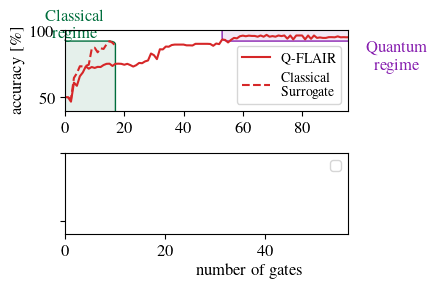

In [128]:
mpl.rcParams.update({'text.usetex':True,'font.size': 12, 'font.family': 'serif', 'font.serif': ['Times', 'Computer Modern']})

color = ['tab:red','orange','tab:purple','green']
fig = plt.figure(figsize=(11.69*0.4, 8.27*0.38))

color_classical_regime = tuple(np.array([0, 110, 61])/255)
color_quantum_regime = tuple(np.array([136, 33, 176])/255)

# Initialize axes first so we can pass them to the function
ax1 = plt.subplot(2, 1, 1) # Left plot (BS)
ax2 = plt.subplot(2, 1, 2) # Right plot (MN)

# ONLY SINGLE DATASET PLOT FOR NOW (USE SECOND PLOT FOR CLASSICAL PARAMETER CURVE)
# ==========================================
# RIGHT PLOT (ax2): logLossMN
# ==========================================
#
# # 1. Q-FLAIR
# name = 'logLossMN'
# path_file_mn = os.path.join(Q_FLAIR_RESULTS_DIR, name, 'ACC_test.txt')
# ACC0 = np.genfromtxt(path_file_mn, usecols=0, skip_header=1)
# ACC1 = np.genfromtxt(path_file_mn, usecols=1, skip_header=1)
# ACC0 = np.array([0.5, *ACC0])
# ACC1 = np.array([0.5, *ACC1])
# ACCaverOpt_mn = (ACC0 + ACC1) * 0.5
# gatesOpt_mn = np.linspace(0, len(ACCaverOpt_mn)-1, len(ACCaverOpt_mn))
#
# # Plot Q-FLAIR
# curve1, = ax2.plot(gatesOpt_mn, ACCaverOpt_mn*100, '-', color=color[2], label='Q-FLAIR', fillstyle='none')
# # 2. Classical Surrogate Benchmark (New)
# # Using max_n_gate=56 based on your original ax2.set_xlim(0, 56+0.5)
# plot_classical_surrogate_acc(
#     name,
#     max_n_gate=125,
#     max_col_name="train_acc",
#     ax=ax2,
#     data_set_color=color[2],
# )

# ==========================================
# LEFT PLOT (ax1): logLossBS
# ==========================================

# 1. Q-FLAIR (Optimized gate)
name = 'logLossBS'
path_file_bs = os.path.join(Q_FLAIR_RESULTS_DIR, name, 'ACC_test.txt')
ACC0 = np.genfromtxt(path_file_bs, usecols=0, skip_header=1)
ACC1 = np.genfromtxt(path_file_bs, usecols=1, skip_header=1)
ACC0 = np.array([0.5, *ACC0])
ACC1 = np.array([0.5, *ACC1])
ACCaverOpt_bs = (ACC0 + ACC1) * 0.5
gatesOpt_bs = np.linspace(0, len(ACCaverOpt_bs)-1, len(ACCaverOpt_bs))

# Plot Q-FLAIR
curve2, = ax1.plot(gatesOpt_bs, ACCaverOpt_bs*100, '-', color=color[0], label='Q-FLAIR', fillstyle='none')

# 2. Classical Surrogate Benchmark (New)
# Using max_n_gate=95 based on your original ax1.set_xlim(0, 95+0.5)
_, comb_df = plot_classical_surrogate_acc(
    name,
    max_n_gate=95,
    max_col_name="train_acc",
    ax=ax1,
    data_set_color=color[0]
)

# Add regime boxes:
classical_accs = comb_df['val_acc'].to_numpy() * 100
quantum_accs = np.asarray(ACCaverOpt_bs) * 100
n_gates = comb_df['n_gate'].to_numpy()
max_classical_acc = classical_accs.max()
add_rounded_box(ax1, (-10, -10), (n_gates.max(), max_classical_acc), c=color_classical_regime, alpha=0.1, header="Classical\nregime")
n_gates = np.arange(len(quantum_accs))
n_gates_quantum_regime = n_gates[quantum_accs > max_classical_acc]
print(n_gates_quantum_regime)
if len(n_gates_quantum_regime) > 0:
    add_rounded_box(ax1, (n_gates_quantum_regime.min(), max_classical_acc), (len(n_gates) + 20, 110), c=color_quantum_regime, alpha=0.1, footer="Quantum\nregime")

# ==========================================
# FORMATTING
# ==========================================

# Right Plot Limits (MN)
ax2.set_xlim(0, 56 + 0.5)
ax2.set_ylim(0.4 * 100, 1 * 100)
ax2.tick_params(labelleft=False) # Hide Y labels on the right plot
ax2.legend(fontsize='small')

# Left Plot Limits (BS)
ax1.set_xlim(0, 95 + 0.5)
ax1.set_ylim(0.4 * 100, 1 * 100)
ax1.set_ylabel(r'accuracy [\%]', fontsize='medium')
ax1.legend(fontsize='small')

# Global Labels
fig.supxlabel('number of gates', y=0.1, x=0.55, fontsize='medium')


plt.tight_layout()
#plt.savefig('Acc_classical_surrogate_paper.pdf')
plt.show()